In [6]:
import sys
!"{sys.executable}" -m pip install --upgrade neo4j langchain-community

  Using cached neo4j-6.2.0-py3-none-any.whl.metadata (5.3 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
Using cached neo4j-6.2.0-py3-none-any.whl (327 kB)
Using cached langchain_community-0.4.2-py3-none-any.whl (2.4 MB)

  Attempting uninstall: neo4j

    Found existing installation: neo4j 5.14.0

    Uninstalling neo4j-5.14.0:

      Successfully uninstalled neo4j-5.14.0

   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------------------- 0/2 [neo4j]
   ---------------------------

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
## Get the enviroment variables from the .env file
NEO4J_URI = os.getenv('NEO4J_URI')
NEO4J_USERNAME = os.getenv('NEO4J_USERNAME')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
NEO4J_DATABASE = os.getenv('NEO4J_DATABASE')

In [2]:
from langchain_community.graphs import Neo4jGraph

## Get the graph from the database
graph = Neo4jGraph(
    url = NEO4J_URI, 
    username = NEO4J_USERNAME,
    password = NEO4J_PASSWORD,
    database= NEO4J_DATABASE
)

graph

C:\Users\dhruv\AppData\Local\Temp\ipykernel_22668\2865499233.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.graphs import Neo4jGraph
C:\Users\dhruv\AppData\Local\Temp\ipykernel_22668\2865499233.py:4: LangChainDeprecationWarning: The class `Neo4jGraph` was deprecated in LangChain 0.3.8 and will be removed in 1.0. An updated version of the class exists in the `langchain-neo4j package and should be used instead. To use it run `pip install -U `langchain-neo4j` and import as `from `langchain_neo4j import Neo4jGraph``.
  graph = Neo4jGraph(


In [4]:
moview_query="""
LOAD CSV WITH HEADERS FROM
'https://raw.githubusercontent.com/tomasonjo/blog-datasets/main/movies/movies_small.csv' as row

MERGE(m:Movie{id:row.movieId})
SET m.released = date(row.released),
    m.title = row.title,
    m.imdbRating = toFloat(row.imdbRating)
FOREACH (director in split(row.director, '|') | 
    MERGE (p:Person {name:trim(director)})
    MERGE (p)-[:DIRECTED]->(m))
FOREACH (actor in split(row.actors, '|') | 
    MERGE (p:Person {name:trim(actor)})
    MERGE (p)-[:ACTED_IN]->(m))
FOREACH (genre in split(row.genres, '|') | 
    MERGE (g:Genre {name:trim(genre)})
    MERGE (m)-[:IN_GENRE]->(g))


"""

print(moview_query)


LOAD CSV WITH HEADERS FROM
'https://raw.githubusercontent.com/tomasonjo/blog-datasets/main/movies/movies_small.csv' as row

MERGE(m:Movie{id:row.movieId})
SET m.released = date(row.released),
    m.title = row.title,
    m.imdbRating = toFloat(row.imdbRating)
FOREACH (director in split(row.director, '|') | 
    MERGE (p:Person {name:trim(director)})
    MERGE (p)-[:DIRECTED]->(m))
FOREACH (actor in split(row.actors, '|') | 
    MERGE (p:Person {name:trim(actor)})
    MERGE (p)-[:ACTED_IN]->(m))
FOREACH (genre in split(row.genres, '|') | 
    MERGE (g:Genre {name:trim(genre)})
    MERGE (m)-[:IN_GENRE]->(g))





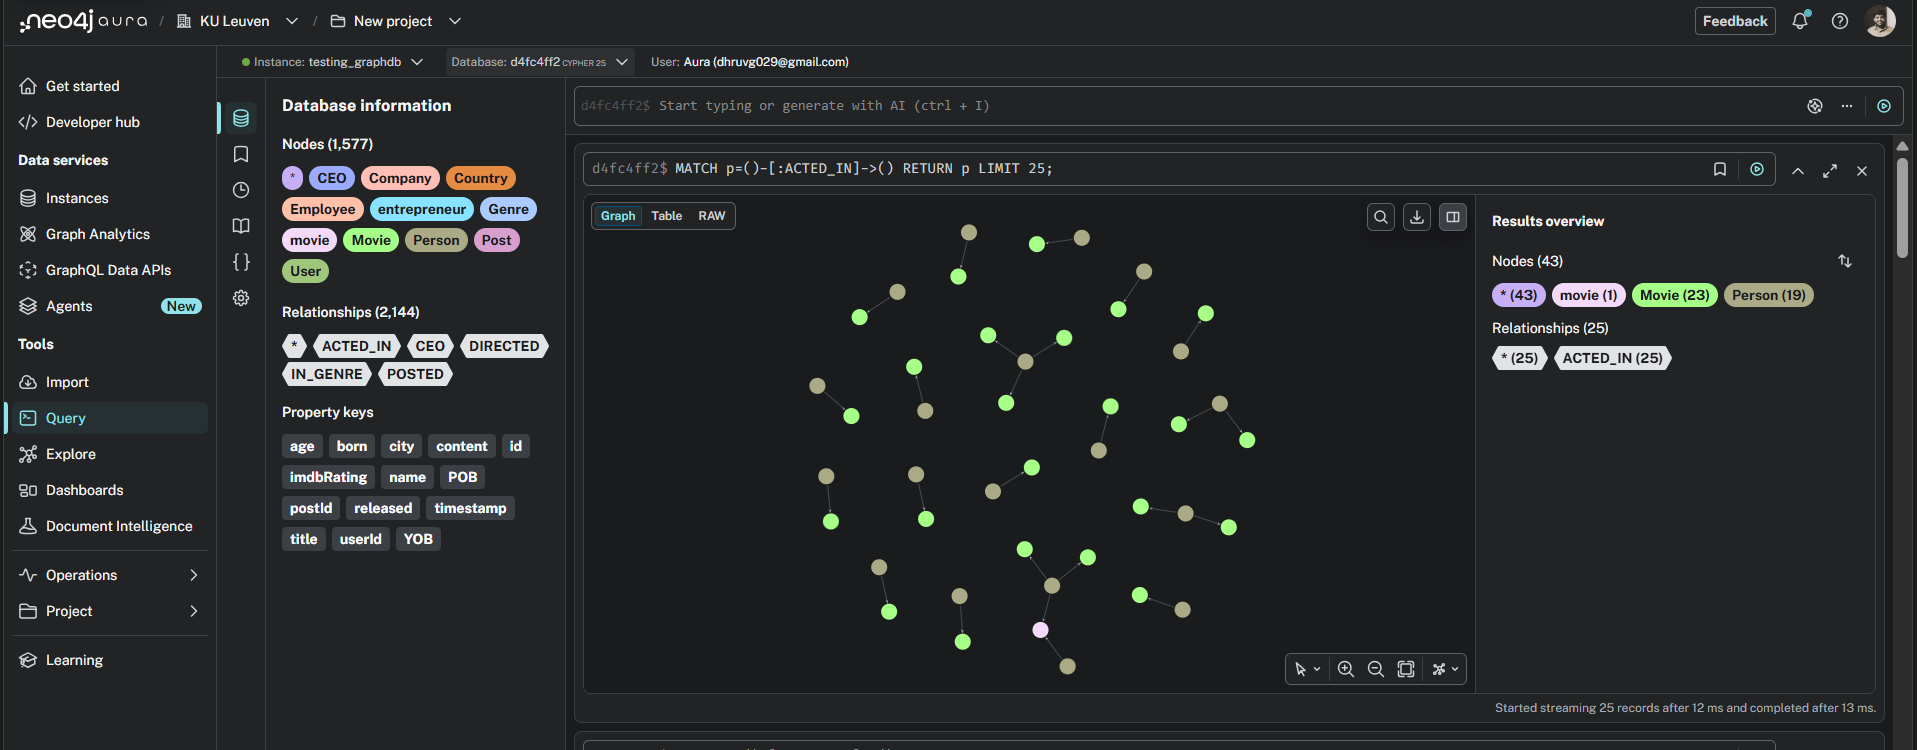

In [5]:
## Query using the Cypher language
graph.query(moview_query)

## Refresh the schema and print it
graph.refresh_schema()
print(graph.schema)

Node properties:
CEO {POB: STRING, YOB: INTEGER, name: STRING}
Company {name: STRING}
entrepreneur {POB: STRING, YOB: INTEGER, name: STRING}
Country {name: STRING}
Person {name: STRING, born: INTEGER}
movie {name: STRING, released: INTEGER}
User {name: STRING, city: STRING, age: INTEGER, userId: INTEGER}
Post {content: STRING, postId: INTEGER, timestamp: DATE_TIME}
Movie {released: DATE, id: STRING, title: STRING, imdbRating: FLOAT}
Genre {name: STRING}
Relationship properties:

The relationships:
(:Person)-[:ACTED_IN]->(:movie)
(:Person)-[:ACTED_IN]->(:Movie)
(:Person)-[:DIRECTED]->(:Movie)
(:User)-[:POSTED]->(:Post)
(:Movie)-[:IN_GENRE]->(:Genre)


In [6]:
from langchain_groq import ChatGroq

## Fetch the Groq LLM
groq_api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    api_key = groq_api_key,
    temperature = 0
)

llm

d:\Udemy Material\Langchain-V2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001766A892BA0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001766A8938C0>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
from langchain_classic.chains import GraphCypherQAChain

## Create the graph QnA chain
chain = GraphCypherQAChain.from_llm(
    graph = graph,
    llm = llm,
    verbose = True,
    exclude_types = ["Genre"],
    
    ## New parameter added recently
    allow_dangerous_requests = True
)

chain

GraphCypherQAChain(verbose=True, graph=<langchain_community.graphs.neo4j_graph.Neo4jGraph object at 0x0000017642624440>, cypher_generation_chain=LLMChain(verbose=False, prompt=PromptTemplate(input_variables=['question', 'schema'], input_types={}, partial_variables={}, template='Task:Generate Cypher statement to query a graph database.\nInstructions:\nUse only the provided relationship types and properties in the schema.\nDo not use any other relationship types or properties that are not provided.\nSchema:\n{schema}\nNote: Do not include any explanations or apologies in your responses.\nDo not respond to any questions that might ask anything else than for you to construct a Cypher statement.\nDo not include any text except the generated Cypher statement.\n\nThe question is:\n{question}'), llm=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_ou

In [ ]:
## Get the schema of the graph
print(chain.graph_schema)

Node properties are the following:
CEO {POB: STRING, YOB: INTEGER, name: STRING},Company {name: STRING},entrepreneur {POB: STRING, YOB: INTEGER, name: STRING},Country {name: STRING},Person {name: STRING, born: INTEGER},movie {name: STRING, released: INTEGER},User {name: STRING, city: STRING, age: INTEGER, userId: INTEGER},Post {content: STRING, postId: INTEGER, timestamp: DATE_TIME},Movie {released: DATE, id: STRING, title: STRING, imdbRating: FLOAT}
Relationship properties are the following:

The relationships are the following:
(:Person)-[:ACTED_IN]->(:movie),(:Person)-[:ACTED_IN]->(:Movie),(:Person)-[:DIRECTED]->(:Movie),(:User)-[:POSTED]->(:Post)


In [ ]:
## Give some prompting examples
examples = [
    {
        "question": "How many artists are there?",
        "query": "MATCH (a:Person)-[:ACTED_IN]->(:Movie) RETURN count(DISTINCT a)",
    },
    {
        "question": "Which actors played in the movie Casino?",
        "query": "MATCH (m:Movie {{title: 'Casino'}})<-[:ACTED_IN]-(a) RETURN a.name",
    },
    {
        "question": "How many movies has Tom Hanks acted in?",
        "query": "MATCH (a:Person {{name: 'Tom Hanks'}})-[:ACTED_IN]->(m:Movie) RETURN count(m)",
    },
    {
        "question": "List all the genres of the movie Schindler's List",
        "query": "MATCH (m:Movie {{title: 'Schindler\\'s List'}})-[:IN_GENRE]->(g:Genre) RETURN g.name",
    },
    {
        "question": "Which actors have worked in movies from both the comedy and action genres?",
        "query": "MATCH (a:Person)-[:ACTED_IN]->(:Movie)-[:IN_GENRE]->(g1:Genre), (a)-[:ACTED_IN]->(:Movie)-[:IN_GENRE]->(g2:Genre) WHERE g1.name = 'Comedy' AND g2.name = 'Action' RETURN DISTINCT a.name",
    },
    {
        "question": "Which directors have made movies with at least three different actors named 'John'?",
        "query": "MATCH (d:Person)-[:DIRECTED]->(m:Movie)<-[:ACTED_IN]-(a:Person) WHERE a.name STARTS WITH 'John' WITH d, COUNT(DISTINCT a) AS JohnsCount WHERE JohnsCount >= 3 RETURN d.name",
    },
    {
        "question": "Identify movies where directors also played a role in the film.",
        "query": "MATCH (p:Person)-[:DIRECTED]->(m:Movie), (p)-[:ACTED_IN]->(m) RETURN m.title, p.name",
    },
    {
        "question": "Find the actor with the highest number of movies in the database.",
        "query": "MATCH (a:Actor)-[:ACTED_IN]->(m:Movie) RETURN a.name, COUNT(m) AS movieCount ORDER BY movieCount DESC LIMIT 1",
    },
]

In [ ]:
from langchain_core.prompts import FewShotPromptTemplate, PromptTemplate

## Get the prompt template
example_prompt = PromptTemplate.from_template(
    "User input:{question}\n Cypher query:{query}"
)

## Get the few shot prompt templates
prompt = FewShotPromptTemplate(
    examples = examples[:5],
    example_prompt = example_prompt,
    prefix = "You are a Neo4j expert. Given an input question,create a syntactically very accurate Cypher query",
    suffix = "User input: {question}\nCypher query: ",
    input_variables = ["question", "schema"]
)

print(prompt)

input_variables=['question'] input_types={} partial_variables={} examples=[{'question': 'How many artists are there?', 'query': 'MATCH (a:Person)-[:ACTED_IN]->(:Movie) RETURN count(DISTINCT a)'}, {'question': 'Which actors played in the movie Casino?', 'query': "MATCH (m:Movie {{title: 'Casino'}})<-[:ACTED_IN]-(a) RETURN a.name"}, {'question': 'How many movies has Tom Hanks acted in?', 'query': "MATCH (a:Person {{name: 'Tom Hanks'}})-[:ACTED_IN]->(m:Movie) RETURN count(m)"}, {'question': "List all the genres of the movie Schindler's List", 'query': "MATCH (m:Movie {{title: 'Schindler\\'s List'}})-[:IN_GENRE]->(g:Genre) RETURN g.name"}, {'question': 'Which actors have worked in movies from both the comedy and action genres?', 'query': "MATCH (a:Person)-[:ACTED_IN]->(:Movie)-[:IN_GENRE]->(g1:Genre), (a)-[:ACTED_IN]->(:Movie)-[:IN_GENRE]->(g2:Genre) WHERE g1.name = 'Comedy' AND g2.name = 'Action' RETURN DISTINCT a.name"}] example_prompt=PromptTemplate(input_variables=['query', 'question']

In [ ]:
print(prompt.format(question = "How many artists are there?", schema = "foo"))

You are a Neo4j expert. Given an input question,create a syntactically very accurate Cypher query

User input:How many artists are there?
 Cypher query:MATCH (a:Person)-[:ACTED_IN]->(:Movie) RETURN count(DISTINCT a)

User input:Which actors played in the movie Casino?
 Cypher query:MATCH (m:Movie {title: 'Casino'})<-[:ACTED_IN]-(a) RETURN a.name

User input:How many movies has Tom Hanks acted in?
 Cypher query:MATCH (a:Person {name: 'Tom Hanks'})-[:ACTED_IN]->(m:Movie) RETURN count(m)

User input:List all the genres of the movie Schindler's List
 Cypher query:MATCH (m:Movie {title: 'Schindler\'s List'})-[:IN_GENRE]->(g:Genre) RETURN g.name

User input:Which actors have worked in movies from both the comedy and action genres?
 Cypher query:MATCH (a:Person)-[:ACTED_IN]->(:Movie)-[:IN_GENRE]->(g1:Genre), (a)-[:ACTED_IN]->(:Movie)-[:IN_GENRE]->(g2:Genre) WHERE g1.name = 'Comedy' AND g2.name = 'Action' RETURN DISTINCT a.name

User input: How many artists are there?
Cypher query: 


In [22]:
## Get the cypher query chain
chain = GraphCypherQAChain.from_llm(
    graph = graph,
    llm = llm,
    cypher_prompt = prompt,
    verbose = True,

    ## Added this new feature recently
    allow_dangerous_requests = True
)

print(chain)

verbose=True graph=<langchain_community.graphs.neo4j_graph.Neo4jGraph object at 0x0000017642624440> cypher_generation_chain=LLMChain(verbose=False, prompt=FewShotPromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, examples=[{'question': 'How many artists are there?', 'query': 'MATCH (a:Person)-[:ACTED_IN]->(:Movie) RETURN count(DISTINCT a)'}, {'question': 'Which actors played in the movie Casino?', 'query': "MATCH (m:Movie {{title: 'Casino'}})<-[:ACTED_IN]-(a) RETURN a.name"}, {'question': 'How many movies has Tom Hanks acted in?', 'query': "MATCH (a:Person {{name: 'Tom Hanks'}})-[:ACTED_IN]->(m:Movie) RETURN count(m)"}, {'question': "List all the genres of the movie Schindler's List", 'query': "MATCH (m:Movie {{title: 'Schindler\\'s List'}})-[:IN_GENRE]->(g:Genre) RETURN g.name"}, {'question': 'Which actors have worked in movies from both the comedy and action genres?', 'query': "MATCH (a:Person)-[:ACTED_IN]->(:Movie)-[:IN_GENRE]->(g1:Genre), (a)-[:ACTED

In [23]:
## Get the response from the chain
response = chain.invoke(
    "Which actors played in the movie Casino?"
)

response



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie {title: 'Casino'})<-[:ACTED_IN]-(a) RETURN a.name
Full Context:
[{'a.name': 'Robert De Niro'}, {'a.name': 'Joe Pesci'}, {'a.name': 'Sharon Stone'}, {'a.name': 'James Woods'}]

> Finished chain.


{'query': 'Which actors played in the movie Casino?',
 'result': 'Robert De Niro, Joe Pesci, Sharon Stone, and James Woods played in the movie Casino.'}

In [24]:
## Get the response from the chain
response = chain.invoke(
    "Which actors have acted in multiple movies?"
)

response



> Entering new GraphCypherQAChain chain...
Generated Cypher:
cypher
MATCH (a:Person)-[:ACTED_IN]->(m:Movie)
WITH a, COUNT(DISTINCT m) AS movie_count
WHERE movie_count > 1
RETURN a.name, movie_count

Full Context:
[{'a.name': 'Tom Hanks', 'movie_count': 2}, {'a.name': 'Tim Allen', 'movie_count': 2}, {'a.name': 'Robin Williams', 'movie_count': 2}, {'a.name': 'Walter Matthau', 'movie_count': 2}, {'a.name': 'Sophia Loren', 'movie_count': 2}, {'a.name': 'Angela Bassett', 'movie_count': 3}, {'a.name': 'Steve Martin', 'movie_count': 2}, {'a.name': 'Al Pacino', 'movie_count': 2}, {'a.name': 'Robert De Niro', 'movie_count': 3}, {'a.name': 'Val Kilmer', 'movie_count': 2}]

> Finished chain.


{'query': 'Which actors have acted in multiple movies?',
 'result': 'Tom Hanks, Tim Allen, Robin Williams, Walter Matthau, Sophia Loren, Angela Bassett, Steve Martin, Al Pacino, Robert De Niro, and Val Kilmer have acted in multiple movies.'}